In [2]:
%matplotlib inline
# !pip install deeplay deeptrack  # Uncomment if running on Colab/Kaggle.

<!--<badge>--><a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/examples/paper-examples/3-particle_sizing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

# Single particle sizing



## 1. Setup

Imports the objects needed for this example.

In [3]:
import os
import zipfile

import deeplay as dl
import deeptrack as dt
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as IO
import torch


## 2. Loading the Dataset

In [4]:
#experimental_data = np.load('datasets/ParticleSizing/sizing_150nm_227nm_PSL.npy', allow_pickle=True)


IMAGE_SIZE = 64

def download_file_from_google_drive(
    file_id: str,
    root,
):
    try:
        import gdown
    except ModuleNotFoundError:
        raise RuntimeError(
            "To download files from GDrive, 'gdown' is required. You can install it with 'pip install gdown'."
        )
    root = os.path.expanduser(root)
    filename = file_id + ".zip"
    fpath = os.fspath(os.path.join(root, filename))
    os.makedirs(root, exist_ok=True)
    gdown.download(id=file_id, output=fpath, quiet=False)

    return fpath

In [5]:
# Get the dataset id and folder name.
dataset_id = "1FaygrzmEDnXjVe_W3yVfqNTM0Ir5jFkR"
folder_name = "ParticleSizing"
model_id =  "1k3wf9c6BZd6HhdpOaOFd8p6m_c9FXdrk"
# Create the datasets folder if it doesn't exist.
if not os.path.exists("datasets"):
    os.mkdir("datasets")

dataset_path = f"datasets/{folder_name}"

# Skip if dataset already exists and has content.
if os.path.exists(dataset_path) and os.listdir(dataset_path):
    print("Dataset already downloaded.")
else:
    # Make dataset folder if missing.
    if not os.path.exists(dataset_path):
        os.mkdir(dataset_path)

    # Download zip file.
    print(f"Downloading {folder_name}...")
    fpath = download_file_from_google_drive(dataset_id, "datasets")

    # Extract zip file.
    print(f"Extracting {folder_name}...")
    with zipfile.ZipFile(fpath, "r") as zip_ref:
        zip_ref.extractall("datasets")

    # Delete zip file.
    os.remove(fpath)

    # Fix nested folder case.
    nested = f"{dataset_path}/{folder_name}"
    if os.path.isdir(nested) and not os.listdir(dataset_path):
        os.rename(nested, dataset_path)

Dataset already downloaded.


## 2.1 Defining the training set

The training set consists of simulated 64 by 64 pixel images, containing a single particle each. The particles are simulated as spheres with a radius between 100nm and 400nm, and a refractive index between 1.37 and 1.67. Its position in the camera plane is constrained to be within within two pixels of the image center, and is sampled with a normal distribution with standard deviation of 2 pixel units along the axis normal to the camera plane. 

In [6]:
particle = dt.MieSphere(
    position=lambda: (IMAGE_SIZE / 2, IMAGE_SIZE / 2) + np.random.rand(2) * 4 - 2,
    z=lambda: np.random.randn() * 2,
    radius=lambda:1e-7 + 3e-7 * np.random.rand() ,
    refractive_index=lambda: np.random.rand() * 0.3 + 1.37,
    L=8,
    position_unit="pixel",
)

We use a single wavelength brightifeld feature to calculate the field at the camera plane. We aberrate the image with a random coma, which was observed in the experimental data. Moreover, the pupil is cropped at high frequencies.

In [7]:
HC = dt.HorizontalComa(coefficient=lambda c1: c1, c1=0 + np.random.randn() * 0.5)
VC = dt.VerticalComa(coefficient=lambda c2:c2, c2=0 + np.random.randn() * 0.5)

def crop(pupil_radius):
    def inner(image):
        x = np.arange(image.shape[0]) - image.shape[0] / 2
        y = np.arange(image.shape[1]) - image.shape[1] / 2
        X, Y = np.meshgrid(x, y)
        image[X ** 2 + Y ** 2 > pupil_radius ** 2] = 0
        return image
    return inner
CROP = dt.Lambda(crop, pupil_radius=23)

optics = dt.Brightfield(
    NA=1.3,
    resolution=1.13e-6,
    wavelength=635e-9,
    aperature_angle=53.7 * 2 * np.pi / 360,
    polarization_angle=lambda: np.random.rand() * 2 * np.pi,
    magnification=10,
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
    padding=(64,) * 4,
    return_field=True,
    pupil= HC >> VC >> CROP
)

The noise is simulated as gaussian distributed noise, with independent real and imaginary parts. The amplitude of the noise is determined by the dummy property `level`, which is explicitly shared between the two features. Finally, the real and imaginary parts of the field are separated into two layers, and the plane wave is subtracted.

In [8]:
real_noise = dt.Gaussian(
    mu=0, 
    sigma=lambda: np.random.rand() * 0.02,
)

noise = real_noise >> dt.Gaussian(
    mu=0, 
    sigma=lambda real_sigma: real_sigma * 0.03j,
    real_sigma=real_noise.sigma
)

def func():
    def inner(image):
        image = image - 1
        output = np.zeros((*image.shape[:2], 2))
        output[..., 0:1] = np.real(image)
        output[..., 1:2] = np.imag(image)
        return output
    return inner


complex_to_float = dt.Lambda(func)

We now define how these objects combine. Note that the noise is added inside the optics. This means that it will have the same PSF as the sample, which is what is observed. 

In [34]:
simulated_particle = (
    dt.Value(optics(particle >> noise))
    >> complex_to_float
)

## 2.2 Defining the training label

We extract the parameters we want the network to learn. We also rescale them such that they have a similar size.

In [46]:
def get_label(image):
    px = np.array(image.get_property("position")) - IMAGE_SIZE / 2
    z = image.get_property("z") * 0.1
    r = image.get_property("radius") / 1e-6
    n = image.get_property("refractive_index") - 1.33
    return np.array([r * 10, n * 10])


pipeline = (
        (
        simulated_particle
            >> dt.MoveAxis(-1, 0)) & get_label(simulated_particle()
    )
) >> dt.pytorch.ToTensor(dtype=torch.float)
pipeline.store_properties()


## 2.3 Visualizing the dataset

We resolve and show 16 images

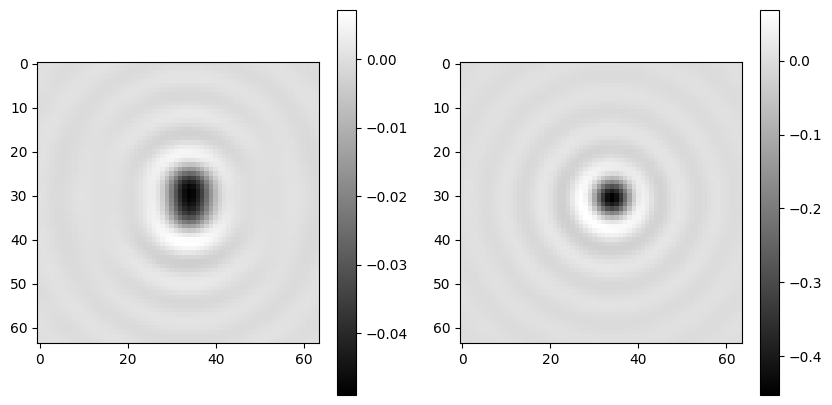

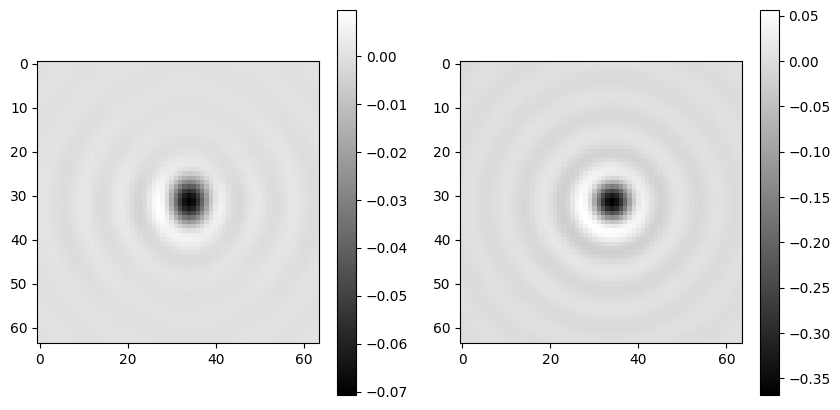

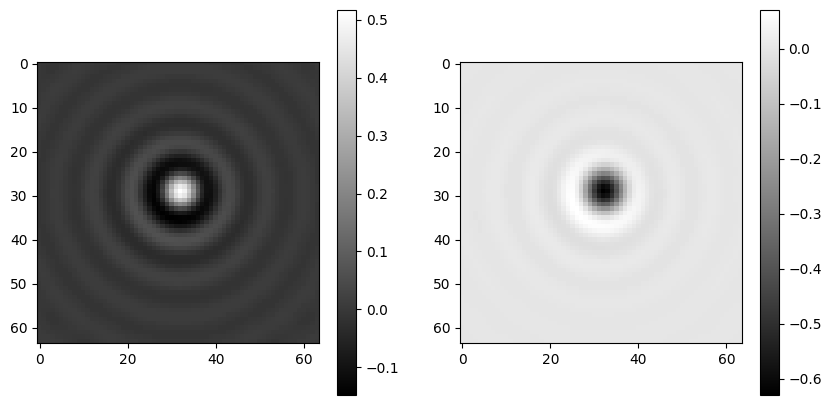

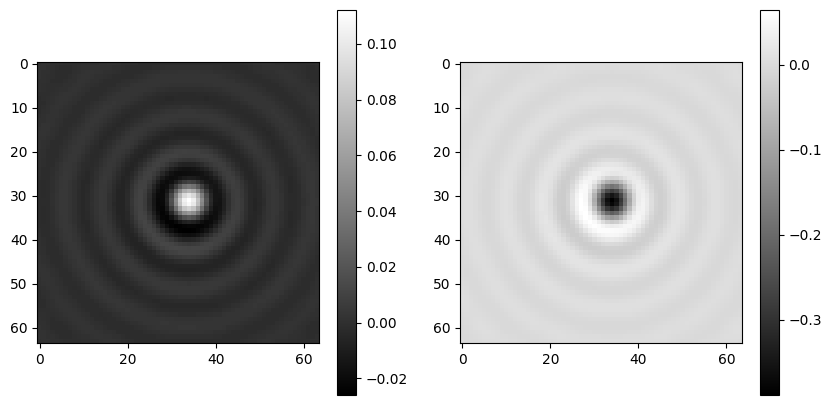

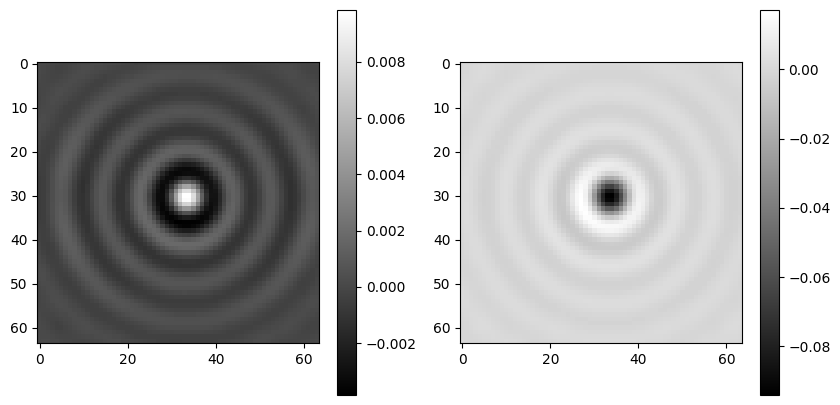

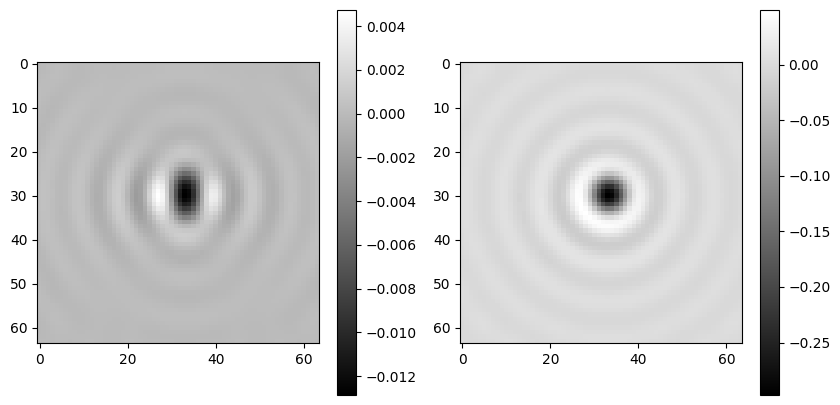

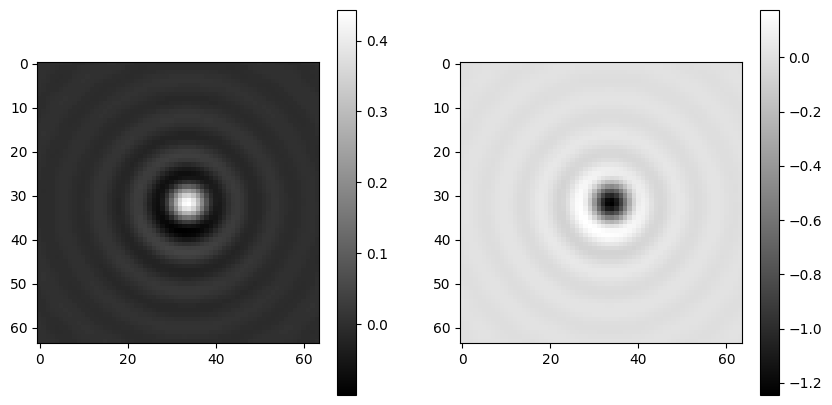

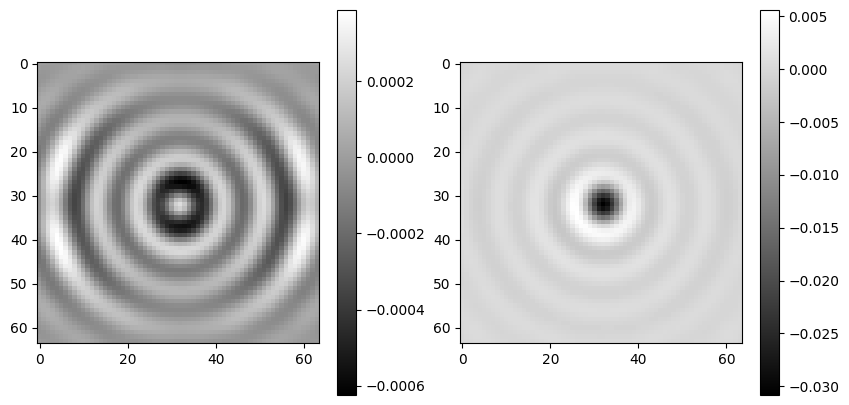

In [48]:
## NUMBER_OF_IMAGES = 16

for i in range(8):
    simulated_particle.update()
    image_of_particle = simulated_particle.resolve()

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(image_of_particle[ :, :, 0], cmap="gray")
    plt.colorbar()
    
    plt.subplot(1,2,2)
    plt.imshow(image_of_particle[:, :, 1], cmap="gray")
    plt.colorbar()
    plt.show()


## 3. Defining the network

The network used is a Convolutional network, with a the pixel error as loss.

In [52]:
cnn = dl.ConvolutionalNeuralNetwork(
    in_channels=None,
    hidden_channels=[32, 64, 128],
    out_channels=1
)
cnn.blocks[-1].pooled(dl.Layer(torch.nn.MaxPool2d, 2).new())
dense_top = dl.MultiLayerPerceptron(
    in_features=None,
    flatten_input=True,
    hidden_features=[64, 64],
    out_features=2
)
model = dl.Sequential([cnn, dense_top])

cnn_regressor = dl.Regressor(
    model=model,
    optimizer=dl.Adam(lr=1e-3),
).build()

print(model)

"""
model = dt.models.Convolutional(
input_shape=(IMAGE_SIZE, IMAGE_SIZE, 2),
conv_layers_dimensions=(32, 64, 128),
dense_layers_dimensions=(64, 64),
steps_per_pooling=2,
number_of_outputs=2,
dropout=(.2, .2),
loss="mae",
optimizer="adam",
dense_block=dt.layers.DenseBlock(activation="relu")
)

model.summary()
"""


Sequential(
  (0): ConvolutionalNeuralNetwork(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): LazyConv2d(0, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU()
      )
      (1): Conv2dBlock(
        (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU()
      )
      (2): Conv2dBlock(
        (layer): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU()
      )
      (3): Conv2dBlock(
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (layer): Conv2d(128, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): Identity()
      )
    )
  )
  (1): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): LazyLinear(in_features=0, out_features=64, bias=True)
        (activation): ReLU()
      )
      (1): LinearBlock(
        (layer): Linear(in_featur

'\nmodel = dt.models.Convolutional(\ninput_shape=(IMAGE_SIZE, IMAGE_SIZE, 2),\nconv_layers_dimensions=(32, 64, 128),\ndense_layers_dimensions=(64, 64),\nsteps_per_pooling=2,\nnumber_of_outputs=2,\ndropout=(.2, .2),\nloss="mae",\noptimizer="adam",\ndense_block=dt.layers.DenseBlock(activation="relu")\n)\n\nmodel.summary()\n'

## 4. Training the network

We use the `ContinuousGenerator` to generate the images. It creates a new thread and generates images while the model is training. 

Set TRAIN_MODEL to True to train the model, otherwise a pretrained model is downloaded.


  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | train
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | Sequential       | 97.8 K | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
97.8 K    Trainable params
0         Non-trainable params
97.8 K    Total params
0.391     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

(<Figure size 1500x500 with 1 Axes>,
 array([[<Axes: title={'center': 'Loss'}, xlabel='Step'>]], dtype=object))

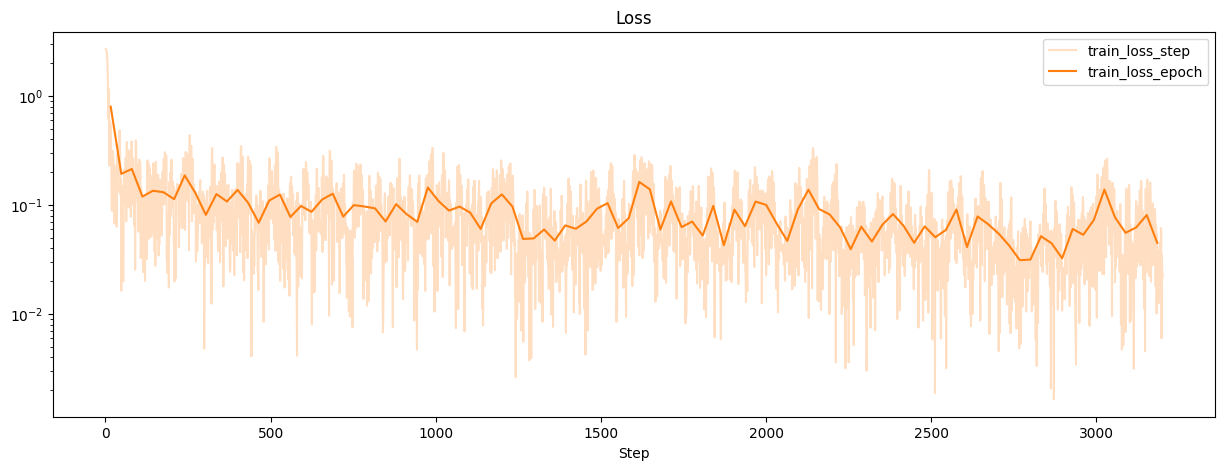

In [53]:
dataset = dt.pytorch.Dataset(
    pipeline,
    length=128,
)
dataloader = dl.DataLoader(
    dataset,
    batch_size=4
)
cnn_trainer = dl.Trainer(max_epochs=100, accelerator="auto")
cnn_trainer.fit(cnn_regressor, dataloader)
cnn_trainer.history.plot()

In [62]:

validation_set_size = 12
validation_set = [pipeline.update().resolve() for _ in range(validation_set_size)]
validation_labels = [get_label(image[0]) for image in validation_set]


## 5. Evaluating the network

We show the the error as a function of some properties.

In [75]:
print(validation_prediction)
print(validation_labels[0])

tensor([[2.0438, 3.3576]], grad_fn=<AddmmBackward0>)
[3.37523091 2.80113509]


In [ ]:
properties = ["radius", "refractive_index", "sigma"]
idx = 0
validation_prediction = model(validation_set[0][idx]._value).detach()

validation_error = [validation_prediction - validation_labels[idx]]
error_names = ["radius", "refractive index"]

for property_name in properties:
    property_values = np.array([image.get_property(property_name) for image in validation_set])
    if property_values.ndim == 1:
        property_values = np.expand_dims(property_values, axis=-1)
    
    for col in range(property_values.shape[1]):
        values = property_values[:, col]

        plt.subplot(1, property_values.shape[1], col + 1)
        for validation_error in validation_errors:
            plt.scatter(values, validation_error, alpha=1)
        plt.xlim([np.min(values), np.max(values)])
        plt.ylim([np.min(validation_error), np.max(validation_error)])
        plt.yscale("log")
        plt.ylabel("Absolute error")
        plt.xlabel("{0}[{1}]".format(property_name, col))
        
    plt.legend(error_names)

    
    plt.show()

AttributeError: 'list' object has no attribute 'get_property'

We estimate the size of particles using experimentally captured images. The particles were traced, so we display the average size and refractive index measured by the model over the trace.

6/6 [==============================] - 0s 3ms/step
2.9173846


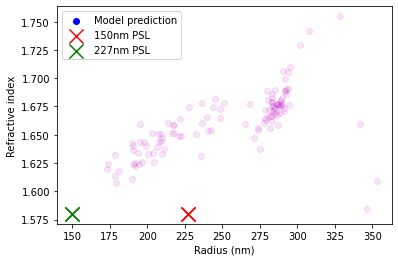

In [12]:
predictions = np.array([
        np.mean(
            model.predict(
                np.array(experimental_data[idx])
            ),
            axis=0
        ) for idx in range(len(experimental_data))
])

print(np.mean(predictions))
plt.scatter([],[], c='b', alpha=1)
plt.scatter(0.227 * 1000, 1.58, marker='x', s=200, c='r')
plt.scatter(0.15 * 1000, 1.58, marker='x', s=200, c='g')

plt.scatter(predictions[:, 0] * 100, predictions[:, 1] / 10 + 1.33, c='m', alpha=0.1)
plt.scatter(0.227 * 1000, 1.58, marker='x', s=200, c='r')
plt.scatter(0.15 * 1000, 1.58, marker='x', s=200, c='g')


plt.legend(["Model prediction", "150nm PSL", "227nm PSL"])
# plt.axis([100, 300, 1.4, 1.7])
plt.xlabel('Radius (nm)')
plt.ylabel('Refractive index')
plt.show()